In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("cleaned_data.csv")

df.head(10)

,State,Region,Population_Millions,Literacy_Rate
0,Karnataka,South,61.1,75.4
1,Tamil Nadu,South,72.1,80.1
2,Kerala,South,33.4,94.0
3,Maharashtra,West,112.4,82.3
4,Gujarat,West,60.4,78.0
5,Rajasthan,North,68.5,66.1
6,Punjab,North,27.7,75.8
7,West Bengal,East,91.3,76.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   State                8 non-null      str    
 1   Region               8 non-null      str    
 2   Population_Millions  8 non-null      float64
 3   Literacy_Rate        8 non-null      float64
dtypes: float64(2), str(2)
memory usage: 494.0 bytes


In [4]:
df.describe()

,Population_Millions,Literacy_Rate
count,8.000000,8.000000
mean,65.862500,78.500000
std,27.829529,7.864931
min,27.700000,66.100000
25%,53.650000,75.700000
50%,64.800000,77.150000
75%,76.900000,80.650000
max,112.400000,94.000000


In [5]:
df.isnull().sum()

State                  0
Region                 0
Population_Millions    0
Literacy_Rate          0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numeric columns:")
print(list(numeric_columns))

Numeric columns:
['Population_Millions', 'Literacy_Rate']


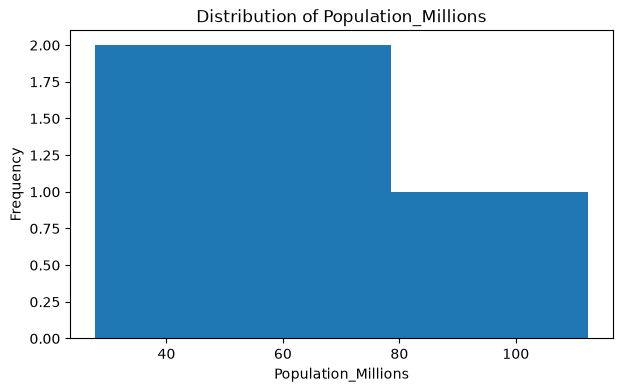

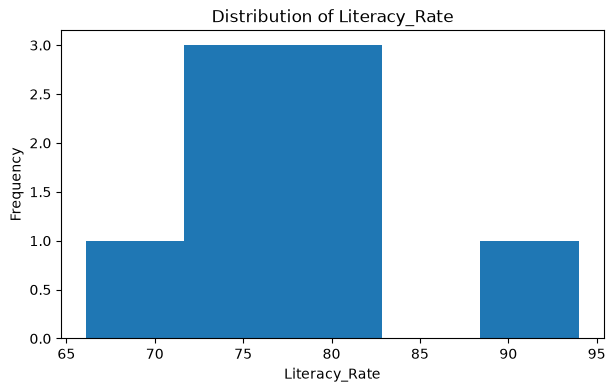

In [8]:
for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[column].dropna(), bins=5)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [9]:
correlation = df[numeric_columns].corr()

print(correlation)

                     Population_Millions  Literacy_Rate
Population_Millions             1.000000      -0.185675
Literacy_Rate                  -0.185675       1.000000


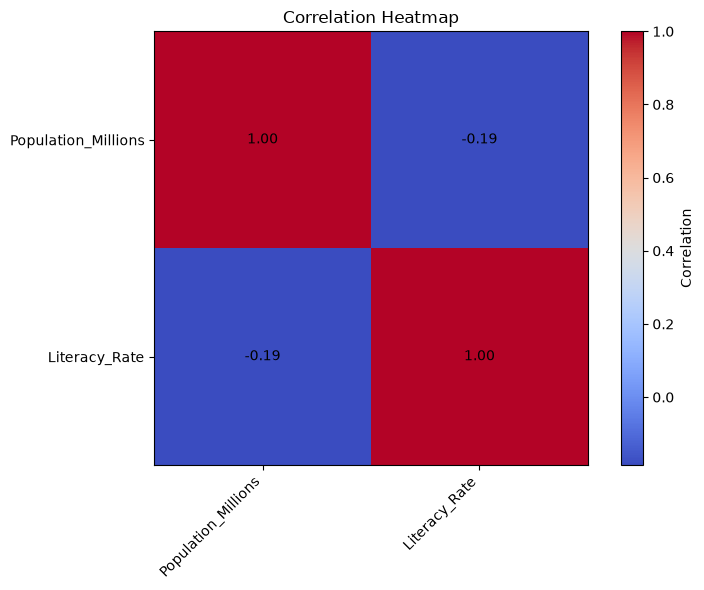

In [14]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm", interpolation="none")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [11]:
top_states = df["State"].value_counts().head(10)

print(top_states)

State
Karnataka      1
Tamil Nadu     1
Kerala         1
Maharashtra    1
Gujarat        1
Rajasthan      1
Punjab         1
West Bengal    1
Name: count, dtype: int64


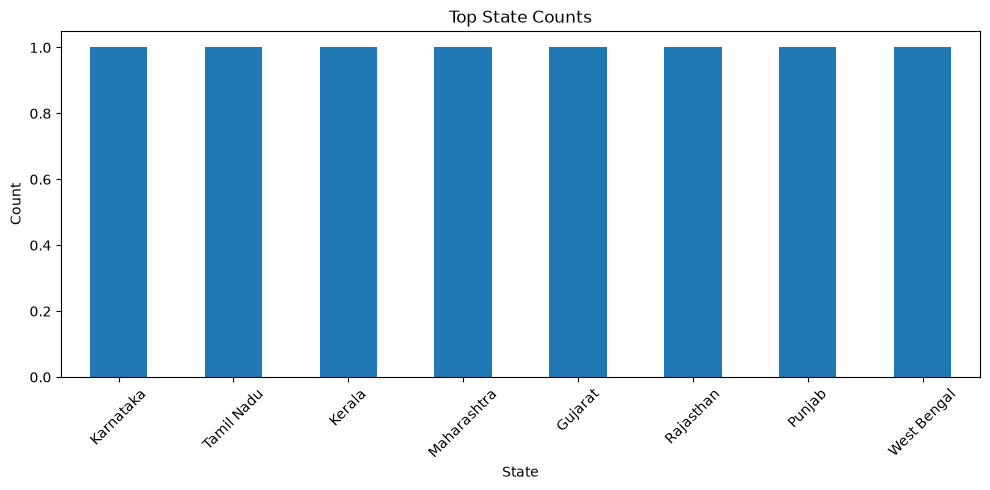

In [12]:
plt.figure(figsize=(10, 5))

top_states.plot(kind="bar")

plt.title("Top State Counts")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
correlation = df[numeric_columns].corr()
print(correlation)

                     Population_Millions  Literacy_Rate
Population_Millions             1.000000      -0.185675
Literacy_Rate                  -0.185675       1.000000


## 5 EDA Observations

1. The dataset contains 8 records and 4 columns, including two numerical and two categorical variables.

2. The average population of the states in the dataset is 65.86 million, with values ranging from 27.7 million to 112.4 million.

3. The average literacy rate is 78.5%, with values ranging from 66.1% to 94.0%.

4. There are no missing values or duplicate records in the dataset, so the current data is structurally complete.

5. The population and literacy-rate distributions show variation between states, while the correlation heatmap helps identify the relationship between these two numerical variables.

## EDA Narrative

The dataset contains information about eight states across four variables: State, Region, Population_Millions, and Literacy_Rate. The exploratory analysis shows that the dataset contains two numerical variables and two categorical variables. The average population is 65.86 million, with values ranging from 27.7 million to 112.4 million. This indicates considerable variation in population size among the states. The average literacy rate is 78.5%, with values ranging from 66.1% to 94.0%, showing noticeable differences in literacy levels.

The dataset is structurally clean because there are no missing values and no duplicate records. The distribution plots show variation in both population and literacy rate, while the correlation heatmap helps examine the relationship between the two numerical variables. The category-count analysis also shows the frequency of the states included in the dataset.

One potentially important area to investigate is the large difference between the minimum and maximum population values, which may indicate variation or possible outliers. Before using this dataset for machine learning, the numerical features should be examined further for outliers and relationships. Additional preprocessing may also be required depending on the ML objective. Overall, the dataset is clean and suitable for further exploratory analysis and preprocessing.


## W1D4 Self-Review

- [x] Loaded the dataset successfully
- [x] Used `df.info()`
- [x] Used `df.describe()`
- [x] Checked missing values using `df.isnull().sum()`
- [x] Checked duplicate records
- [x] Plotted distributions of numeric columns
- [x] Created a correlation heatmap
- [x] Created a top-10 category count chart
- [x] Documented 5 EDA observations
- [x] Wrote the EDA narrative
- [x] Reviewed the notebook outputs
- [ X] Completed two CIA interactions
- [ X] Applied useful CIA feedback